#**SUPPORT VECTOR MACHINE**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report)
from sklearn.svm import SVC
from sklearn.decomposition import PCA


In [ ]:
df = pd.read_csv("Pharma_Industry.csv")

### **Task 1: Exploratory Data Analysis (EDA)**

In [ ]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [ ]:
print("Shape:", df.shape)

Shape: (500, 6)


In [ ]:
print("\nData types:\n", df.dtypes)


Data types:
 Drug Dosage (mg)                  float64
Systolic Blood Pressure (mmHg)    float64
Heart Rate (BPM)                  float64
Liver Toxicity Index (U/L)        float64
Blood Glucose Level (mg/dL)       float64
Drug Response                       int64
dtype: object


In [ ]:
print("Missing Values:\n",df.isna().sum())

Missing Values:
 Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64


In [ ]:
# Rename columns for convenience
df = df.rename(columns={'Drug Dosage (mg)': 'dosage','Systolic Blood Pressure (mmHg)': 'sbp','Heart Rate (BPM)': 'hr',
    'Liver Toxicity Index (U/L)': 'liver','Blood Glucose Level (mg/dL)': 'glucose','Drug Response': 'response'})

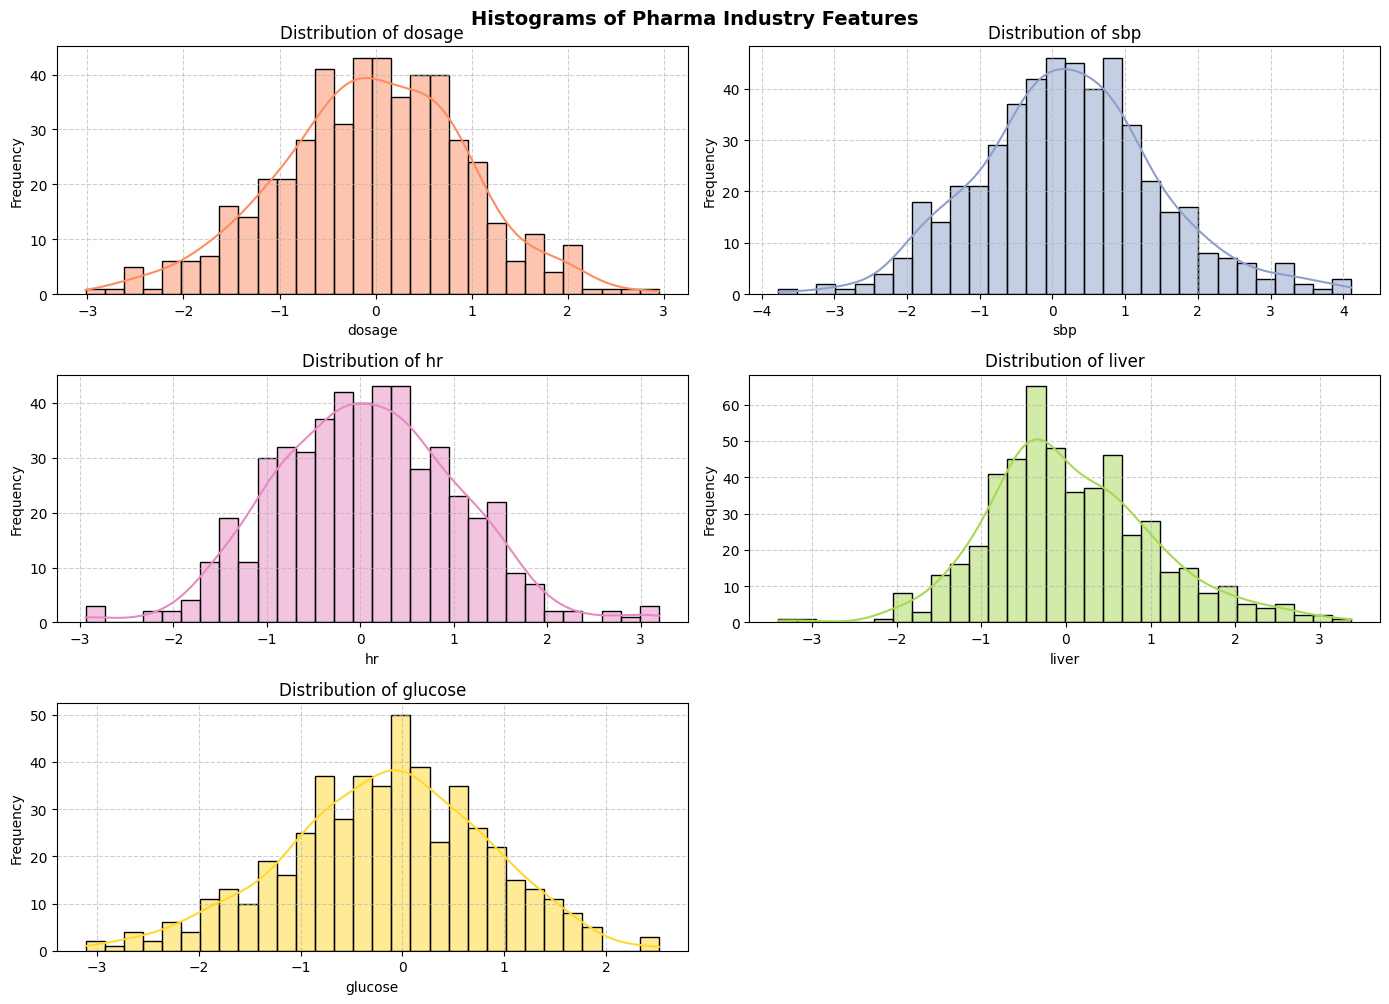

In [ ]:
plt.figure(figsize=(14,10))
for i, col in enumerate(features, 1):
    plt.subplot(3,2,i)
    sns.histplot(df[col], bins=30, kde=True, color=sns.color_palette("Set2")[i])
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.suptitle("Histograms of Pharma Industry Features",fontsize=14,weight='bold', y=1.00)
plt.show()


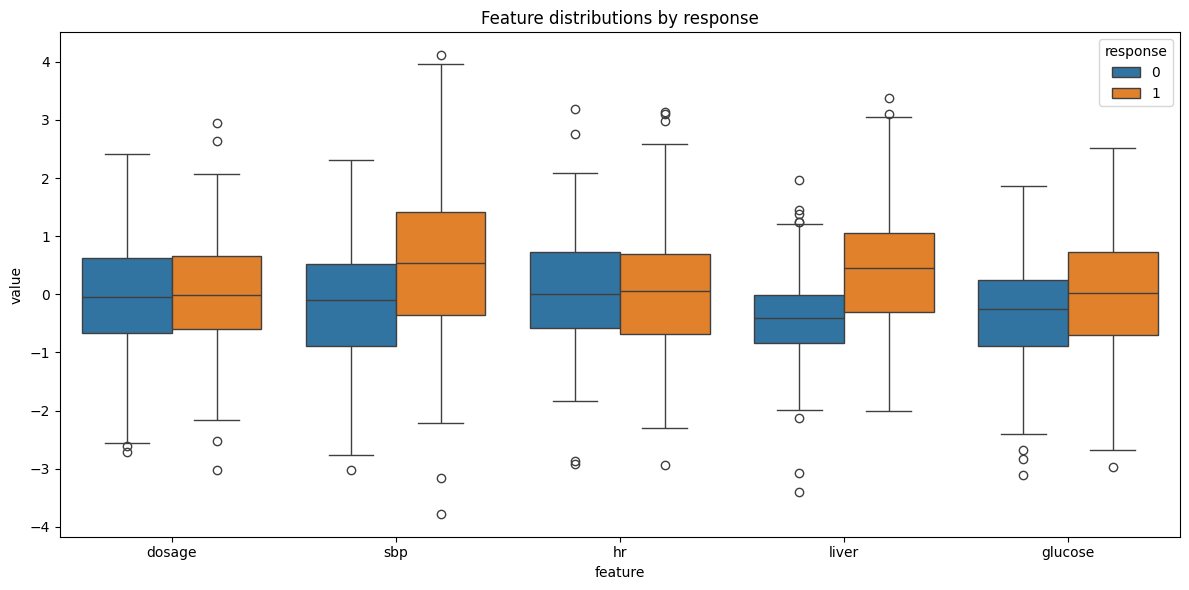

In [ ]:
# Boxplots
plt.figure(figsize=(12,))
melted = df.melt(id_vars='response', value_vars=features,
                 var_name='feature', value_name='value')
sns.boxplot(data=melted, x='feature', y='value', hue='response')
plt.title("Feature distributions by response")
plt.tight_layout()
plt.show()

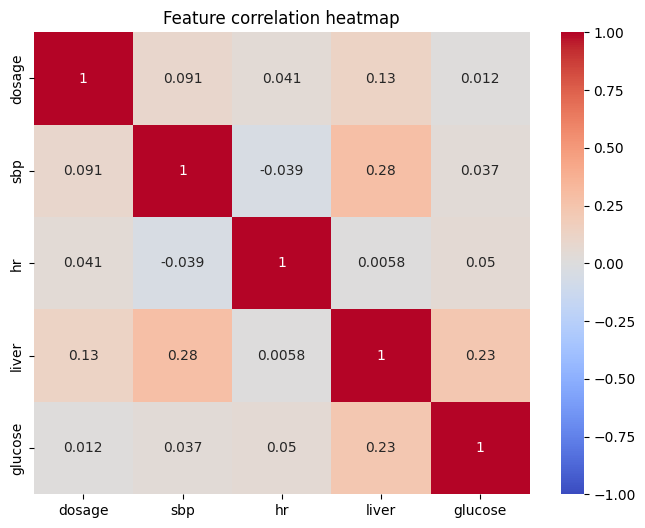

In [ ]:
# Correlation heatmap
plt.figure(figsize=(8,6))
corr = df[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1)
plt.title("Feature correlation heatmap")
plt.show()

### **Task 2: Data Preprocessing**

In [ ]:
# Features and target
x = df[['dosage', 'sbp', 'hr', 'liver', 'glucose']]
y = df['response']

# 2. Split dataset into training and testing sets (stratified to preserve class balance)
x_train, x_test, y_train, y_test = train_test_split(
    x, y,test_size=0.25,stratify=y, random_state=42
)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(375, 5)
(125, 5)
(375,)
(125,)


In [ ]:
# Scale features (important for SVM)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("First 5 scaled training rows:\n", x_train_scaled[:5])

First 5 scaled training rows:
 [[-2.29158924 -1.32483407  1.49782911 -0.42267978  0.69172356]
 [ 0.47527745 -0.17654663 -0.99830988 -0.36642938  0.37677343]
 [ 0.19394054  0.65616463  1.10735046 -3.15561502 -3.11428632]
 [-0.82436033 -1.36607468 -0.68826452  1.07018933 -1.4419206 ]
 [ 1.24133336  0.11358344  1.48553252 -0.55349135 -0.66515005]]


###**Task 3: Data Visualization**

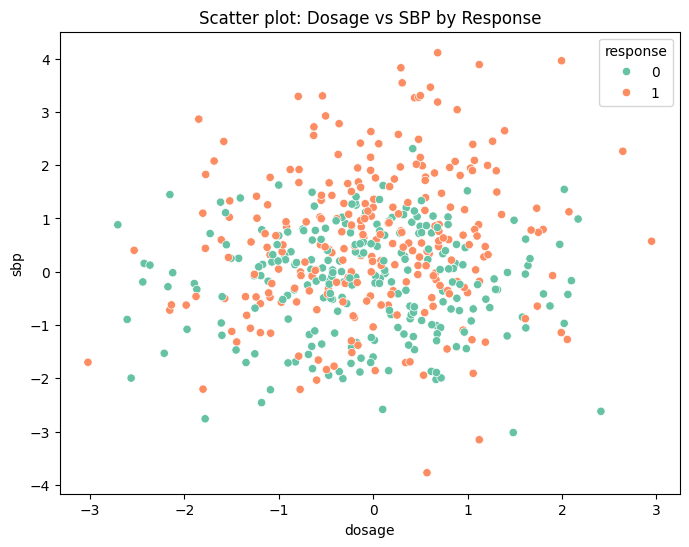

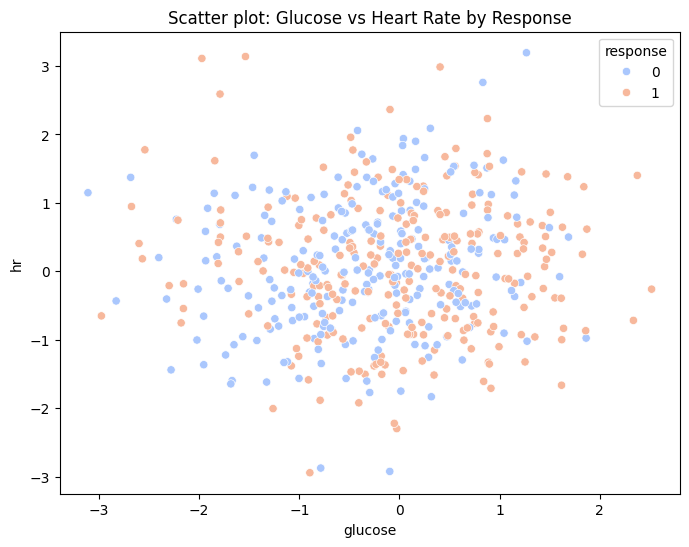

In [ ]:
# Scatter plots for feature relationships
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='dosage', y='sbp', hue='response', palette='Set2')
plt.title("Scatter plot: Dosage vs SBP by Response")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='glucose', y='hr', hue='response', palette='coolwarm')
plt.title("Scatter plot: Glucose vs Heart Rate by Response")
plt.show()

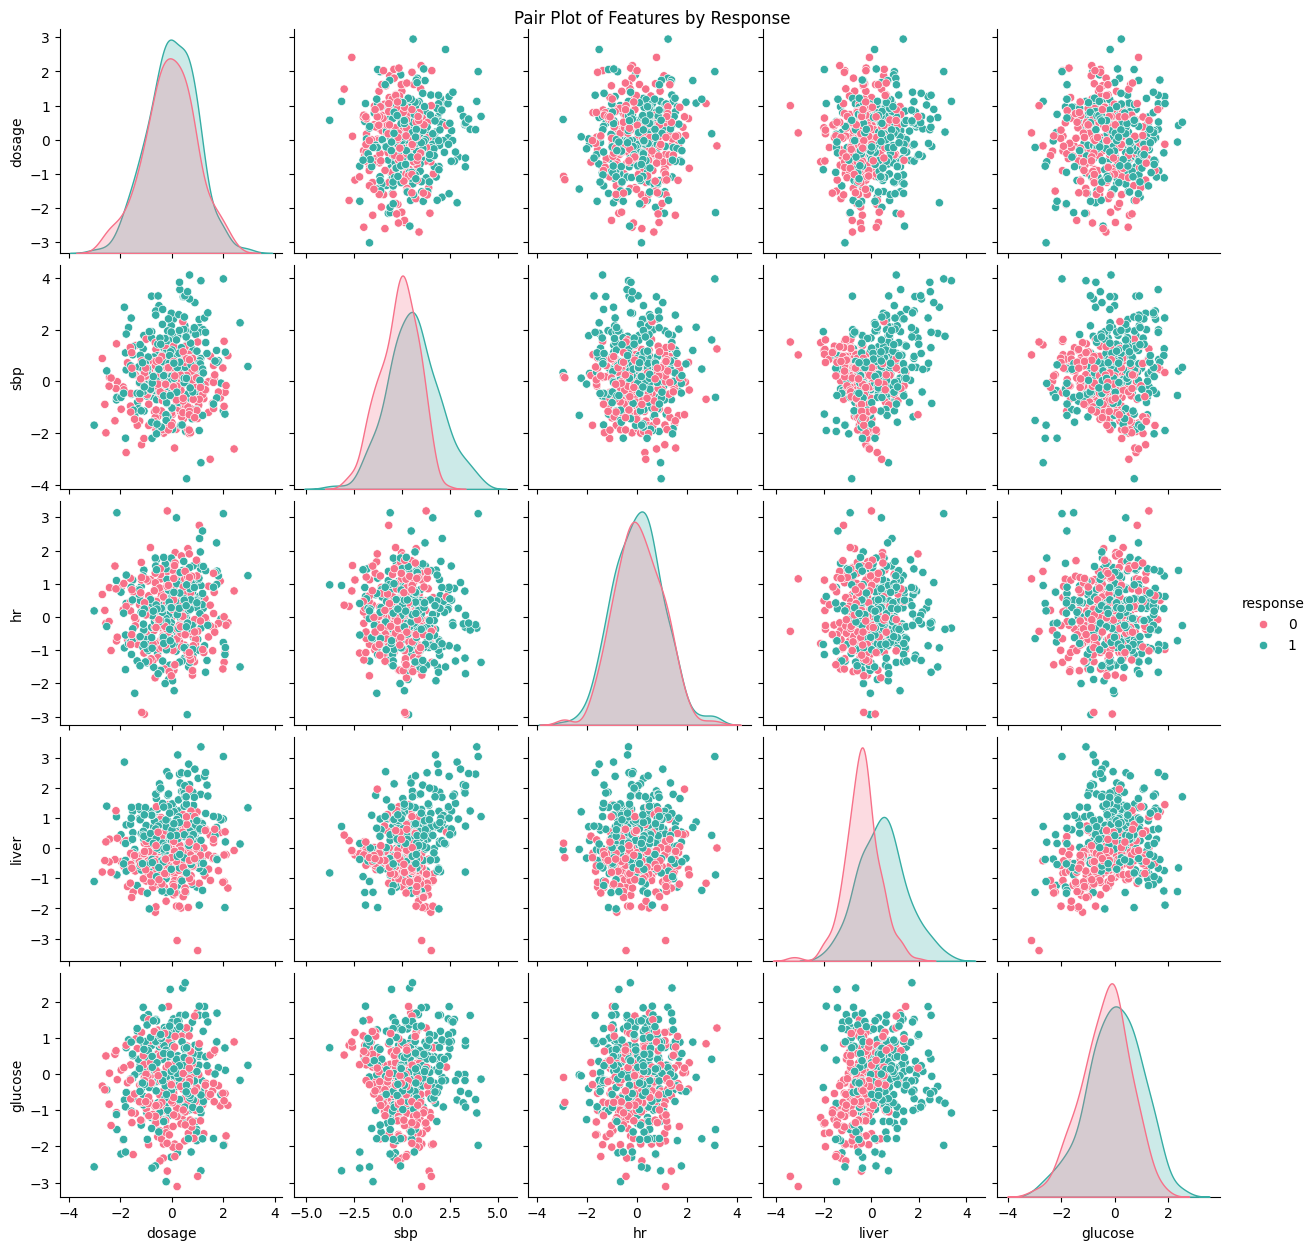

In [ ]:
# Pair plot for all features
sns.pairplot(df[['dosage','sbp','hr','liver','glucose','response']],
             hue='response', diag_kind='kde', palette='husl')
plt.suptitle("Pair Plot of Features by Response", y=1.0)
plt.show()

/tmp/ipython-input-570412523.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='response', palette='Set1')


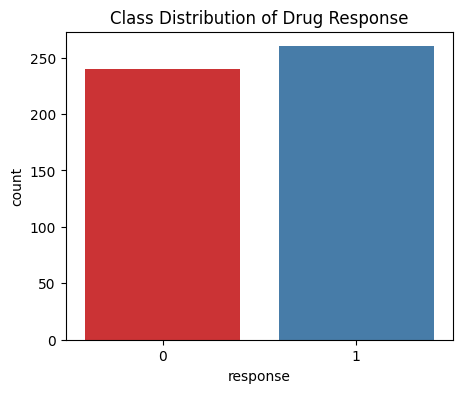

In [ ]:
# Class distribution (balance check)
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='response', palette='Set1')
plt.title("Class Distribution of Drug Response")
plt.show()





###**Task 4: SVM Implementation**

In [ ]:
# Train SVM with default linear kernel
svm_model = SVC(kernel='linear', random_state=42)

In [ ]:
# Train the model
svm_model.fit(x_train_scaled, y_train)

SVC(kernel='linear', random_state=42)

In [ ]:
# Predictions
y_pred = svm_model.predict(x_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.728
Precision: 0.7719298245614035
Recall: 0.676923076923077
F1-score: 0.7213114754098361

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.78      0.73        60
           1       0.77      0.68      0.72        65

    accuracy                           0.73       125
   macro avg       0.73      0.73      0.73       125
weighted avg       0.73      0.73      0.73       125



###**Task 5: Visualization of SVM Results**

In [ ]:
# Reduce to 2D using PCA for visualization
pca = PCA(n_components=2, random_state=42)
x_test_pca = pca.fit_transform(x_test_scaled)
x_test_pca = pca.transform(x_test_scaled)

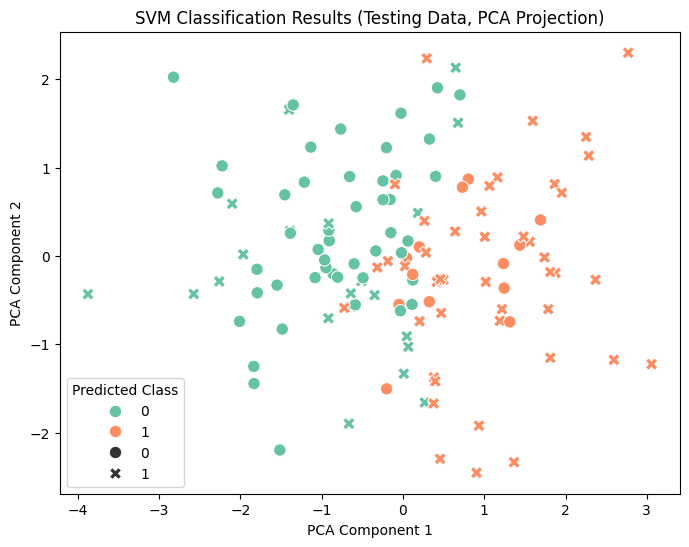

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=x_test_pca[:,0], y=x_test_pca[:,1],
                hue=y_pred, style=y_test, palette="Set2", s=80)
plt.title("SVM Classification Results (Testing Data, PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Predicted Class")
plt.show()


###**Task 6: Parameter Tuning and Optimization**

In [ ]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

In [ ]:
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(x_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Score:", grid.best_score_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation Score: 0.76


###**Task 7: Comparison and Analysis**

In [ ]:
kernels = ['linear', 'poly', 'rbf']
for k in kernels:
    model = SVC(kernel=k, C=1, gamma='scale', random_state=42)
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    print(f"Kernel: {k}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("-"*60)

Kernel: linear
Accuracy: 0.728
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.78      0.73        60
           1       0.77      0.68      0.72        65

    accuracy                           0.73       125
   macro avg       0.73      0.73      0.73       125
weighted avg       0.73      0.73      0.73       125

------------------------------------------------------------
Kernel: poly
Accuracy: 0.688
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.68      0.68        60
           1       0.70      0.69      0.70        65

    accuracy                           0.69       125
   macro avg       0.69      0.69      0.69       125
weighted avg       0.69      0.69      0.69       125

------------------------------------------------------------
Kernel: rbf
Accuracy: 0.752
Classification Report:
               precision    recall  f1-score   support

         

##**Analyzing SVM Strengths and Weaknesses**
**Strengths:**

*  ***Effective in high-dimensional spaces*** :Works well with multiple biological markers (dosage, glucose, toxicity).
- ***Robust to overfitting*** : With proper regularization (C), SVM generalizes well.
- ***Kernel trick*** : Allows modeling of non-linear relationships (important for drug response data).

**Weaknesses**
- ***Computationally expensive*** : Training can be slow on very large datasets.
- ***Parameter sensitivity***: Performance depends heavily on kernel choice, C, and gamma.
- ***Less interpretable***: Compared to decision trees or logistic regression, SVM decision boundaries are harder to explain to clinicians.


##**Practical Implications of SVM in Real-World Classification Tasks**
- ***Pharmaceutical Industry***:
  - SVM can predict drug response early in clinical trials, reducing costs and risks.
  - Helps identify which patients are likely to benefit from a drug.
- ***Personalized Medicine***:
  - Supports tailoring treatments to individual patients based on biomarkers.
  - Improves patient outcomes by avoiding ineffective drugs.
- ***Healthcare Applications***:
  - Useful in disease diagnosis, biomarker classification, and treatment response prediction.
  - Ensures better resource allocation in hospitals and research labs.
